In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/genre_cleaned.csv')

In [3]:
df.shape

(4547837, 40)

In [4]:
df.head()

,bpm,bpm_histogram_first_peak_bpm_mean,bpm_histogram_first_peak_bpm_median,bpm_histogram_second_peak_bpm_mean,bpm_histogram_second_peak_bpm_median,danceability,onset_rate,average_loudness,dynamic_complexity,mfcc_zero_mean,...,key_key_B,key_key_C,key_key_C#,key_key_D,key_key_D#,key_key_E,key_key_F,key_key_F#,key_key_G,key_key_G#
0,132.114716,133.0,133.0,117.0,117.0,0.963751,2.697139,0.939739,2.026948,-601.399475,...,0,0,0,1,0,0,0,0,0,0
1,95.068558,96.0,96.0,88.0,88.0,1.064906,2.686261,0.687424,3.005937,-683.606689,...,0,0,0,1,0,0,0,0,0,0
2,89.911079,91.0,91.0,120.0,120.0,1.050370,5.002318,0.647487,4.984218,-649.677856,...,0,0,0,0,0,0,0,0,0,0
3,97.024086,98.0,98.0,91.0,91.0,1.348803,3.769673,0.948725,2.141814,-612.465271,...,0,0,0,0,0,0,0,0,0,0
4,99.880089,99.0,99.0,94.0,94.0,0.963569,3.208771,0.312500,8.135631,-766.415588,...,1,0,0,0,0,0,0,0,0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4547837 entries, 0 to 4547836
Data columns (total 40 columns):
 #   Column                                Dtype  
---  ------                                -----  
 0   bpm                                   float64
 1   bpm_histogram_first_peak_bpm_mean     float64
 2   bpm_histogram_first_peak_bpm_median   float64
 3   bpm_histogram_second_peak_bpm_mean    float64
 4   bpm_histogram_second_peak_bpm_median  float64
 5   danceability                          float64
 6   onset_rate                            float64
 7   average_loudness                      float64
 8   dynamic_complexity                    float64
 9   mfcc_zero_mean                        float64
 10  tuning_frequency                      float64
 11  tuning_equal_tempered_deviation       float64
 12  key_scale                             int64  
 13  mood_happy_prob                       float64
 14  mood_aggressive_prob                  float64
 15  mood_happy                

Focus on predicting the main_genre for now, so drop sub_genre

In [3]:
df.drop(columns = ['sub_genre'], inplace = True)

In [7]:
df.isna().sum()

bpm                                     0
bpm_histogram_first_peak_bpm_mean       0
bpm_histogram_first_peak_bpm_median     0
bpm_histogram_second_peak_bpm_mean      0
bpm_histogram_second_peak_bpm_median    0
danceability                            0
onset_rate                              0
average_loudness                        0
dynamic_complexity                      0
mfcc_zero_mean                          0
tuning_frequency                        0
tuning_equal_tempered_deviation         0
key_scale                               0
mood_happy_prob                         0
mood_aggressive_prob                    0
mood_happy                              0
mood_sad                                0
mood_relaxed                            0
mood_aggressive                         0
mood_acoustic                           0
mood_electronic                         0
mood_party                              0
voice_gender                            0
timbre                            

In [5]:
df['main_genre'].value_counts()

main_genre
Other               860460
Rock                846829
Electronic          826030
Pop                 340904
Classical           299607
Metal               266171
Jazz                248277
Hip Hop             197972
Punk                119940
Folk                104295
Soundtrack           93399
Country              87465
Reggae               73461
Blues                57792
Experimental         55924
R&B                  29332
Easy Listening       18495
Alternative Rock      9987
Dance                 5154
Techno                3704
Ambient               1701
Soul                   542
Indie Rock             313
Heavy Metal             68
House                   15
Name: count, dtype: int64

Combine genres together using domain knowledge to reduce unique genres 

In [6]:
# Create a dictionary for genre mapping
genre_mapping = {
    'Alternative Rock': 'Rock',
    'Indie Rock': 'Rock',
    'Dance': 'Pop',
    'Techno': 'Electronic',
    'Ambient': 'Electronic',
    'House': 'Electronic',
    'Experimental' : 'Electronic', # added to merge with Electronic (after confusion matrix results)
    'Heavy Metal': 'Metal',
    'Jazz': 'Jazz/Blues',
    'Blues': 'Jazz/Blues',
    'Hip Hop': 'Hip-Hop/R&B',
    'R&B': 'Hip-Hop/R&B',
    # 'Folk': 'Folk/Country',     # remove split (after confusion matrix results)
    # 'Country': 'Folk/Country',
    'Reggae': 'Electronic',    # merge with electronic (after confusion matrix results)
    'Soul': 'Electronic',
}

# Apply the genre mapping
df['main_genre'] = df['main_genre'].replace(genre_mapping)

In [7]:
df['main_genre'].value_counts()

main_genre
Electronic        961377
Other             860460
Rock              857129
Pop               346058
Jazz/Blues        306069
Classical         299607
Metal             266239
Hip-Hop/R&B       227304
Punk              119940
Folk              104295
Soundtrack         93399
Country            87465
Easy Listening     18495
Name: count, dtype: int64

Remove the 'Other' rows

In [8]:
df = df[df['main_genre'] != 'Other']

Remove the other genres to omit from prediction

In [9]:
df = df[df['main_genre'] != 'Easy Listening']
df = df[df['main_genre'] != 'Soundtrack']

In [10]:
df['main_genre'].value_counts()

main_genre
Electronic     961377
Rock           857129
Pop            346058
Jazz/Blues     306069
Classical      299607
Metal          266239
Hip-Hop/R&B    227304
Punk           119940
Folk           104295
Country         87465
Name: count, dtype: int64

Do Label encoding before train test split.
Do train test split with stratified to account for class inbalance

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(df['main_genre'])
X = df.drop(columns=['main_genre'])

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded 
)

# Verify the class distributions
import numpy as np
print("Training class counts:", np.bincount(y_train))
print("Validation class counts:", np.bincount(y_test))


Training class counts: [239686  69972 769102  83436 181843 244855 212991 276846  95952 685703]
Validation class counts: [ 59921  17493 192275  20859  45461  61214  53248  69212  23988 171426]


In [12]:
pd.Series(y_train).value_counts()

2    769102
9    685703
7    276846
5    244855
0    239686
6    212991
4    181843
8     95952
3     83436
1     69972
Name: count, dtype: int64

In [13]:
pd.Series(y_test).value_counts()

2    192275
9    171426
7     69212
5     61214
0     59921
6     53248
4     45461
8     23988
3     20859
1     17493
Name: count, dtype: int64

In [14]:
# Convert the numpy array into a Pandas Series with matching index
y_train = pd.Series(y_train, index=X_train.index, name='main_genre')

# Now concatenate safely
train_df = pd.concat([X_train, y_train], axis=1)

In [15]:
y_test = pd.Series(y_test, index=X_test.index, name='main_genre')

In [16]:
train_df.isna().sum()

bpm                                     0
bpm_histogram_first_peak_bpm_mean       0
bpm_histogram_first_peak_bpm_median     0
bpm_histogram_second_peak_bpm_mean      0
bpm_histogram_second_peak_bpm_median    0
danceability                            0
onset_rate                              0
average_loudness                        0
dynamic_complexity                      0
mfcc_zero_mean                          0
tuning_frequency                        0
tuning_equal_tempered_deviation         0
key_scale                               0
mood_happy_prob                         0
mood_aggressive_prob                    0
mood_happy                              0
mood_sad                                0
mood_relaxed                            0
mood_aggressive                         0
mood_acoustic                           0
mood_electronic                         0
mood_party                              0
voice_gender                            0
timbre                            

In [17]:
train_df.corr()

,bpm,bpm_histogram_first_peak_bpm_mean,bpm_histogram_first_peak_bpm_median,bpm_histogram_second_peak_bpm_mean,bpm_histogram_second_peak_bpm_median,danceability,onset_rate,average_loudness,dynamic_complexity,mfcc_zero_mean,...,key_key_C,key_key_C#,key_key_D,key_key_D#,key_key_E,key_key_F,key_key_F#,key_key_G,key_key_G#,main_genre
bpm,1.000000,0.979718,0.979718,0.598369,0.598369,-0.074148,-0.037792,-0.033461,-0.008251,0.035506,...,0.000587,-0.001582,0.011188,-0.003769,0.007404,-0.011595,-0.000365,0.007882,-0.002216,0.013210
bpm_histogram_first_peak_bpm_mean,0.979718,1.000000,1.000000,0.584129,0.584129,-0.080533,-0.045668,-0.040952,-0.003292,0.029783,...,0.000811,-0.001598,0.010955,-0.003268,0.007044,-0.011482,-0.000193,0.007843,-0.001976,0.011275
bpm_histogram_first_peak_bpm_median,0.979718,1.000000,1.000000,0.584129,0.584129,-0.080533,-0.045668,-0.040952,-0.003292,0.029783,...,0.000811,-0.001598,0.010955,-0.003268,0.007044,-0.011482,-0.000193,0.007843,-0.001976,0.011275
bpm_histogram_second_peak_bpm_mean,0.598369,0.584129,0.584129,1.000000,1.000000,-0.086859,-0.045642,-0.037646,-0.000427,0.020641,...,0.000646,-0.001650,0.009088,-0.002973,0.006294,-0.008853,0.000347,0.006579,-0.002245,0.011286
bpm_histogram_second_peak_bpm_median,0.598369,0.584129,0.584129,1.000000,1.000000,-0.086859,-0.045642,-0.037646,-0.000427,0.020641,...,0.000646,-0.001650,0.009088,-0.002973,0.006294,-0.008853,0.000347,0.006579,-0.002245,0.011286
danceability,-0.074148,-0.080533,-0.080533,-0.086859,-0.086859,1.000000,0.607739,0.490944,-0.291325,0.244984,...,-0.025889,0.009420,-0.025753,-0.014131,-0.029066,0.034505,-0.012282,-0.043504,0.012878,-0.015772
onset_rate,-0.037792,-0.045668,-0.045668,-0.045642,-0.045642,0.607739,1.000000,0.408194,-0.240811,0.238571,...,-0.022324,-0.001034,-0.024903,-0.014740,-0.028417,0.031484,-0.016475,-0.027439,0.006834,-0.009683
average_loudness,-0.033461,-0.040952,-0.040952,-0.037646,-0.037646,0.490944,0.408194,1.000000,-0.680042,0.688909,...,-0.022321,0.001181,-0.000870,-0.029159,0.005850,0.001948,-0.010117,-0.026844,-0.003553,0.301194
dynamic_complexity,-0.008251,-0.003292,-0.003292,-0.000427,-0.000427,-0.291325,-0.240811,-0.680042,1.000000,-0.740669,...,0.014876,-0.002089,-0.009588,0.018633,-0.009304,0.003592,0.007044,0.015887,0.003573,-0.246608
mfcc_zero_mean,0.035506,0.029783,0.029783,0.020641,0.020641,0.244984,0.238571,0.688909,-0.740669,1.000000,...,-0.021876,-0.000432,0.020705,-0.029030,0.019310,-0.014918,-0.009584,-0.018297,-0.011073,0.374211


Define function to check correlated features above 0.8 threshold

In [18]:
def correlation(dataset, threshold):
    col_corr= set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [19]:
corr_features = correlation(train_df, 0.8)

len(set(corr_features))

3

In [20]:
corr_features

{'bpm_histogram_first_peak_bpm_mean',
 'bpm_histogram_first_peak_bpm_median',
 'bpm_histogram_second_peak_bpm_median'}

Examine which correlated features is most correlated with target main_genre

In [21]:
corr_df = train_df[list(corr_features) + ['main_genre']]

correlations_with_dependent = corr_df.corr()['main_genre']

corr_w_dependent = correlations_with_dependent.drop('main_genre').abs().sort_values(ascending = False).reset_index()

corr_w_dependent

,index,main_genre
0,bpm_histogram_second_peak_bpm_median,0.011286
1,bpm_histogram_first_peak_bpm_median,0.011275
2,bpm_histogram_first_peak_bpm_mean,0.011275


Drop the correlated features except one most correlated w main_genre

In [22]:
X_train.drop(corr_w_dependent['index'][1:], axis = 1, inplace = True)

In [29]:
X_train.isna().sum()

bpm                                    0
bpm_histogram_first_peak_bpm_median    0
bpm_histogram_second_peak_bpm_mean     0
danceability                           0
onset_rate                             0
average_loudness                       0
dynamic_complexity                     0
mfcc_zero_mean                         0
tuning_frequency                       0
tuning_equal_tempered_deviation        0
key_scale                              0
mood_happy_prob                        0
mood_aggressive_prob                   0
mood_happy                             0
mood_sad                               0
mood_relaxed                           0
mood_aggressive                        0
mood_acoustic                          0
mood_electronic                        0
mood_party                             0
voice_gender                           0
timbre                                 0
tonal_atonal                           0
voice_instrumental                     0
key_key_A       

In [22]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 3638269 entries, 4400797 to 962467
Data columns (total 36 columns):
 #   Column                               Dtype  
---  ------                               -----  
 0   bpm                                  float64
 1   bpm_histogram_first_peak_bpm_median  float64
 2   bpm_histogram_second_peak_bpm_mean   float64
 3   danceability                         float64
 4   onset_rate                           float64
 5   average_loudness                     float64
 6   dynamic_complexity                   float64
 7   mfcc_zero_mean                       float64
 8   tuning_frequency                     float64
 9   tuning_equal_tempered_deviation      float64
 10  key_scale                            int64  
 11  mood_happy_prob                      float64
 12  mood_aggressive_prob                 float64
 13  mood_happy                           int64  
 14  mood_sad                             int64  
 15  mood_relaxed                         int64 

Next observe Mutual Information Gain, examine mutual info between each feature and main_genre

In [30]:
from sklearn.feature_selection import mutual_info_classif

mutual_info = mutual_info_classif(X_train, y_train, random_state = 42)
mutual_info

array([0.08395638, 0.04167498, 0.01991549, 0.15848731, 0.1739828 ,
       0.15627603, 0.13801623, 0.19589374, 0.10690869, 0.10155699,
       0.10442153, 0.01716724, 0.06411086, 0.04343311, 0.10478015,
       0.16902081, 0.12563516, 0.14380463, 0.18684119, 0.11006771,
       0.11416227, 0.1253925 , 0.10079912, 0.13920035, 0.00750202,
       0.0146703 , 0.00210517, 0.00493191, 0.00290067, 0.00586059,
       0.00281615, 0.00514783, 0.00670782, 0.00157479, 0.00591586,
       0.00218696])

In [31]:
mutual_info = pd.Series(mutual_info)
mutual_info.index = X_train.columns
mutual_info.sort_values(ascending = False)

mfcc_zero_mean                         0.195894
mood_electronic                        0.186841
onset_rate                             0.173983
mood_relaxed                           0.169021
danceability                           0.158487
average_loudness                       0.156276
mood_acoustic                          0.143805
voice_instrumental                     0.139200
dynamic_complexity                     0.138016
mood_aggressive                        0.125635
timbre                                 0.125392
voice_gender                           0.114162
mood_party                             0.110068
tuning_frequency                       0.106909
mood_sad                               0.104780
key_scale                              0.104422
tuning_equal_tempered_deviation        0.101557
tonal_atonal                           0.100799
bpm                                    0.083956
mood_aggressive_prob                   0.064111
mood_happy                             0

Looks like the key columns are more uninformative

No columns I need to drop

Make sure X_test has same columns as X_train

In [ ]:
columns_to_drop_from_X_test = list(X_test.columns.difference(X_train.columns))

In [ ]:
X_test.drop(columns = columns_to_drop_from_X_test, inplace = True)

In [25]:
X_train.shape

(2860386, 36)

In [26]:
X_test.shape

(715097, 36)

View distribution of each feature

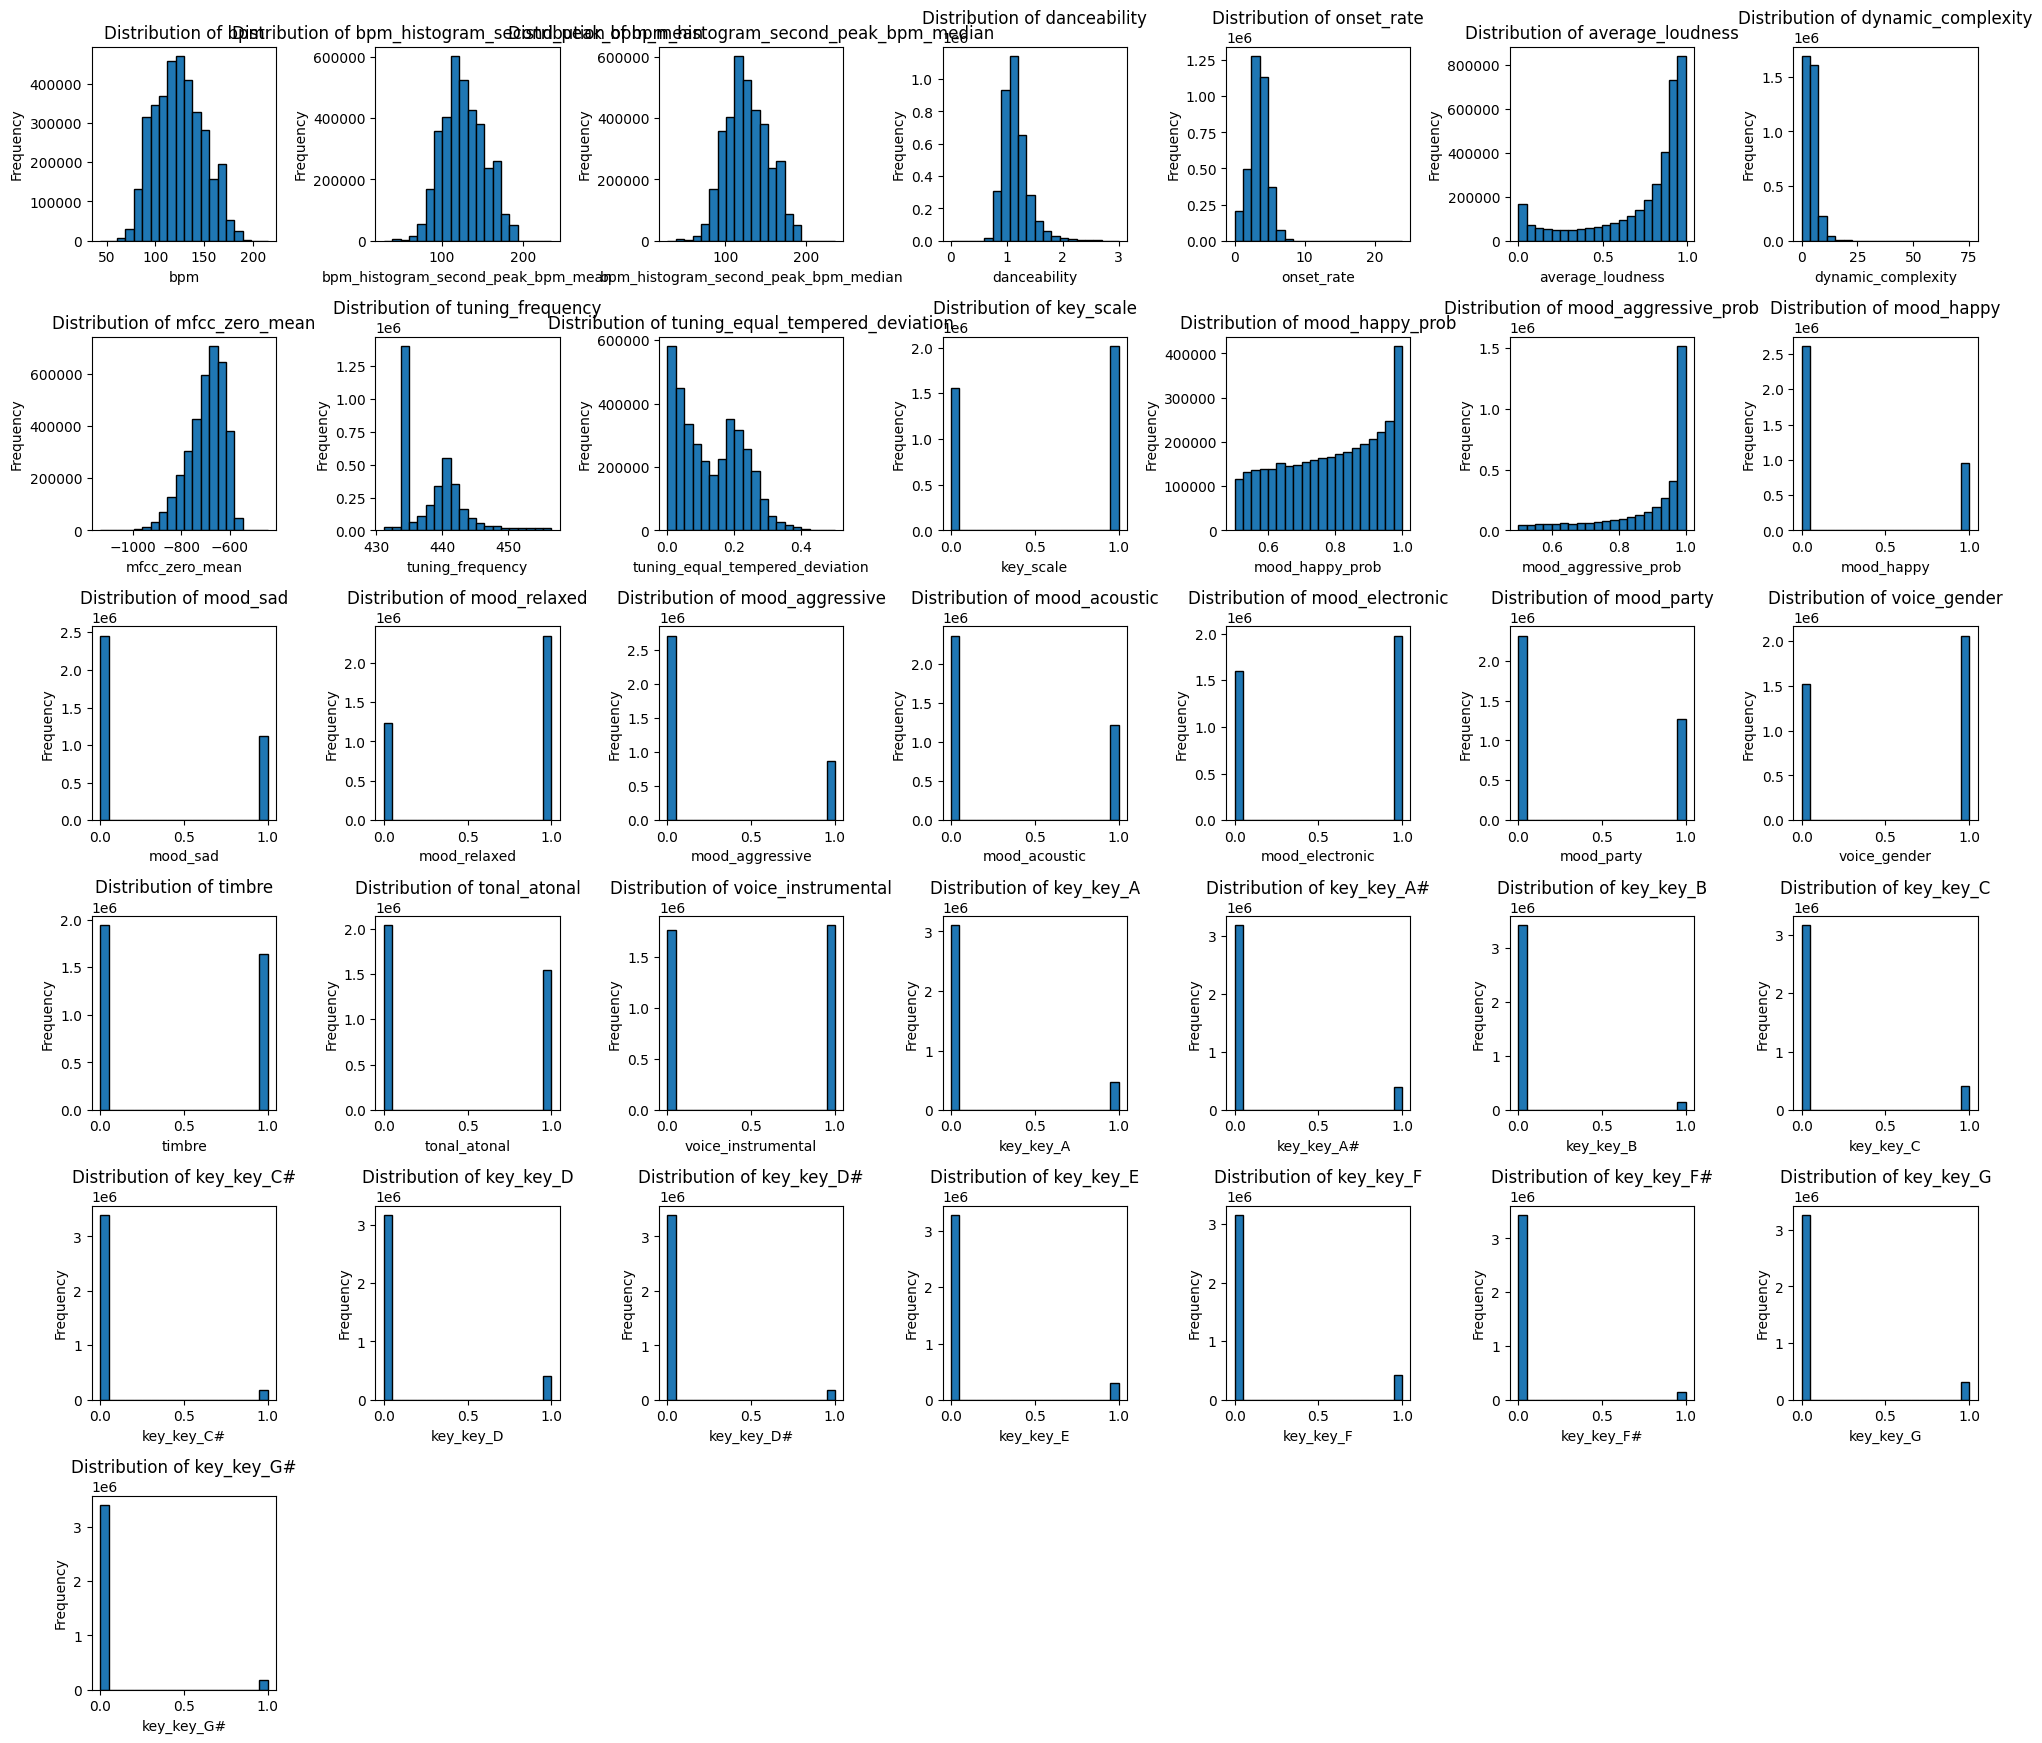

In [27]:
num_cols = len(X_train.columns)
n_cols = 7
n_rows = 7

fig, axes = plt.subplots(nrows=n_rows, ncols = n_cols, figsize=( 20,20))
axes = axes.flatten()

for i, col in enumerate(X_train.columns):
    axes[i].hist(df[col], bins = 20, edgecolor = 'black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for idx in range(num_cols, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

Decide how to scale features:

Leave unscaled
* average_loudness - since using tree based models predominantly


Standard scaling
* bpm
* first mean
* second median
* dancebility
* mfcc_zero_mean
* tuning_frequency - spike is normal frequency

Log transform + standard scaling
* onset_rate
* dynamic complexity
* tuning_equal_tempered_deviation

Min max scaling
* mood happy prob
* mood aggressive prob


Apply Min Max Scaling

In [28]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

scaled_X_train = X_train.copy()
scaled_X_test = X_test.copy()

cols_to_scale = ['mood_happy_prob', 'mood_aggressive_prob']

scaled_X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

scaled_X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [32]:
scaled_X_train.info()

<class 'pandas.DataFrame'>
Index: 2860386 entries, 601385 to 2189456
Data columns (total 36 columns):
 #   Column                                Dtype  
---  ------                                -----  
 0   bpm                                   float64
 1   bpm_histogram_second_peak_bpm_mean    float64
 2   bpm_histogram_second_peak_bpm_median  float64
 3   danceability                          float64
 4   onset_rate                            float64
 5   average_loudness                      float64
 6   dynamic_complexity                    float64
 7   mfcc_zero_mean                        float64
 8   tuning_frequency                      float64
 9   tuning_equal_tempered_deviation       float64
 10  key_scale                             int64  
 11  mood_happy_prob                       float64
 12  mood_aggressive_prob                  float64
 13  mood_happy                            int64  
 14  mood_sad                              int64  
 15  mood_relaxed              

Apply Log + Standard Scaling

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols_for_log = ['onset_rate', 'dynamic_complexity', 'tuning_equal_tempered_deviation']

scaled_X_train[cols_for_log] = np.log1p(X_train[cols_for_log])
scaled_X_test[cols_for_log] = np.log1p(X_test[cols_for_log])

cols_to_scale = ['bpm', 'bpm_histogram_second_peak_bpm_median', 'bpm_histogram_second_peak_bpm_mean', 'danceability', 'mfcc_zero_mean', 'tuning_frequency', 'onset_rate', 'dynamic_complexity', 'tuning_equal_tempered_deviation']

scaled_X_train[cols_to_scale] = scaler.fit_transform(scaled_X_train[cols_to_scale])

scaled_X_test[cols_to_scale] = scaler.transform(scaled_X_test[cols_to_scale])

Convert to DataFrame

In [34]:
scaled_X_train = pd.DataFrame(scaled_X_train, columns = X_train.columns)
scaled_X_test = pd.DataFrame(scaled_X_test, columns = X_test.columns)

View scaled feature distributions

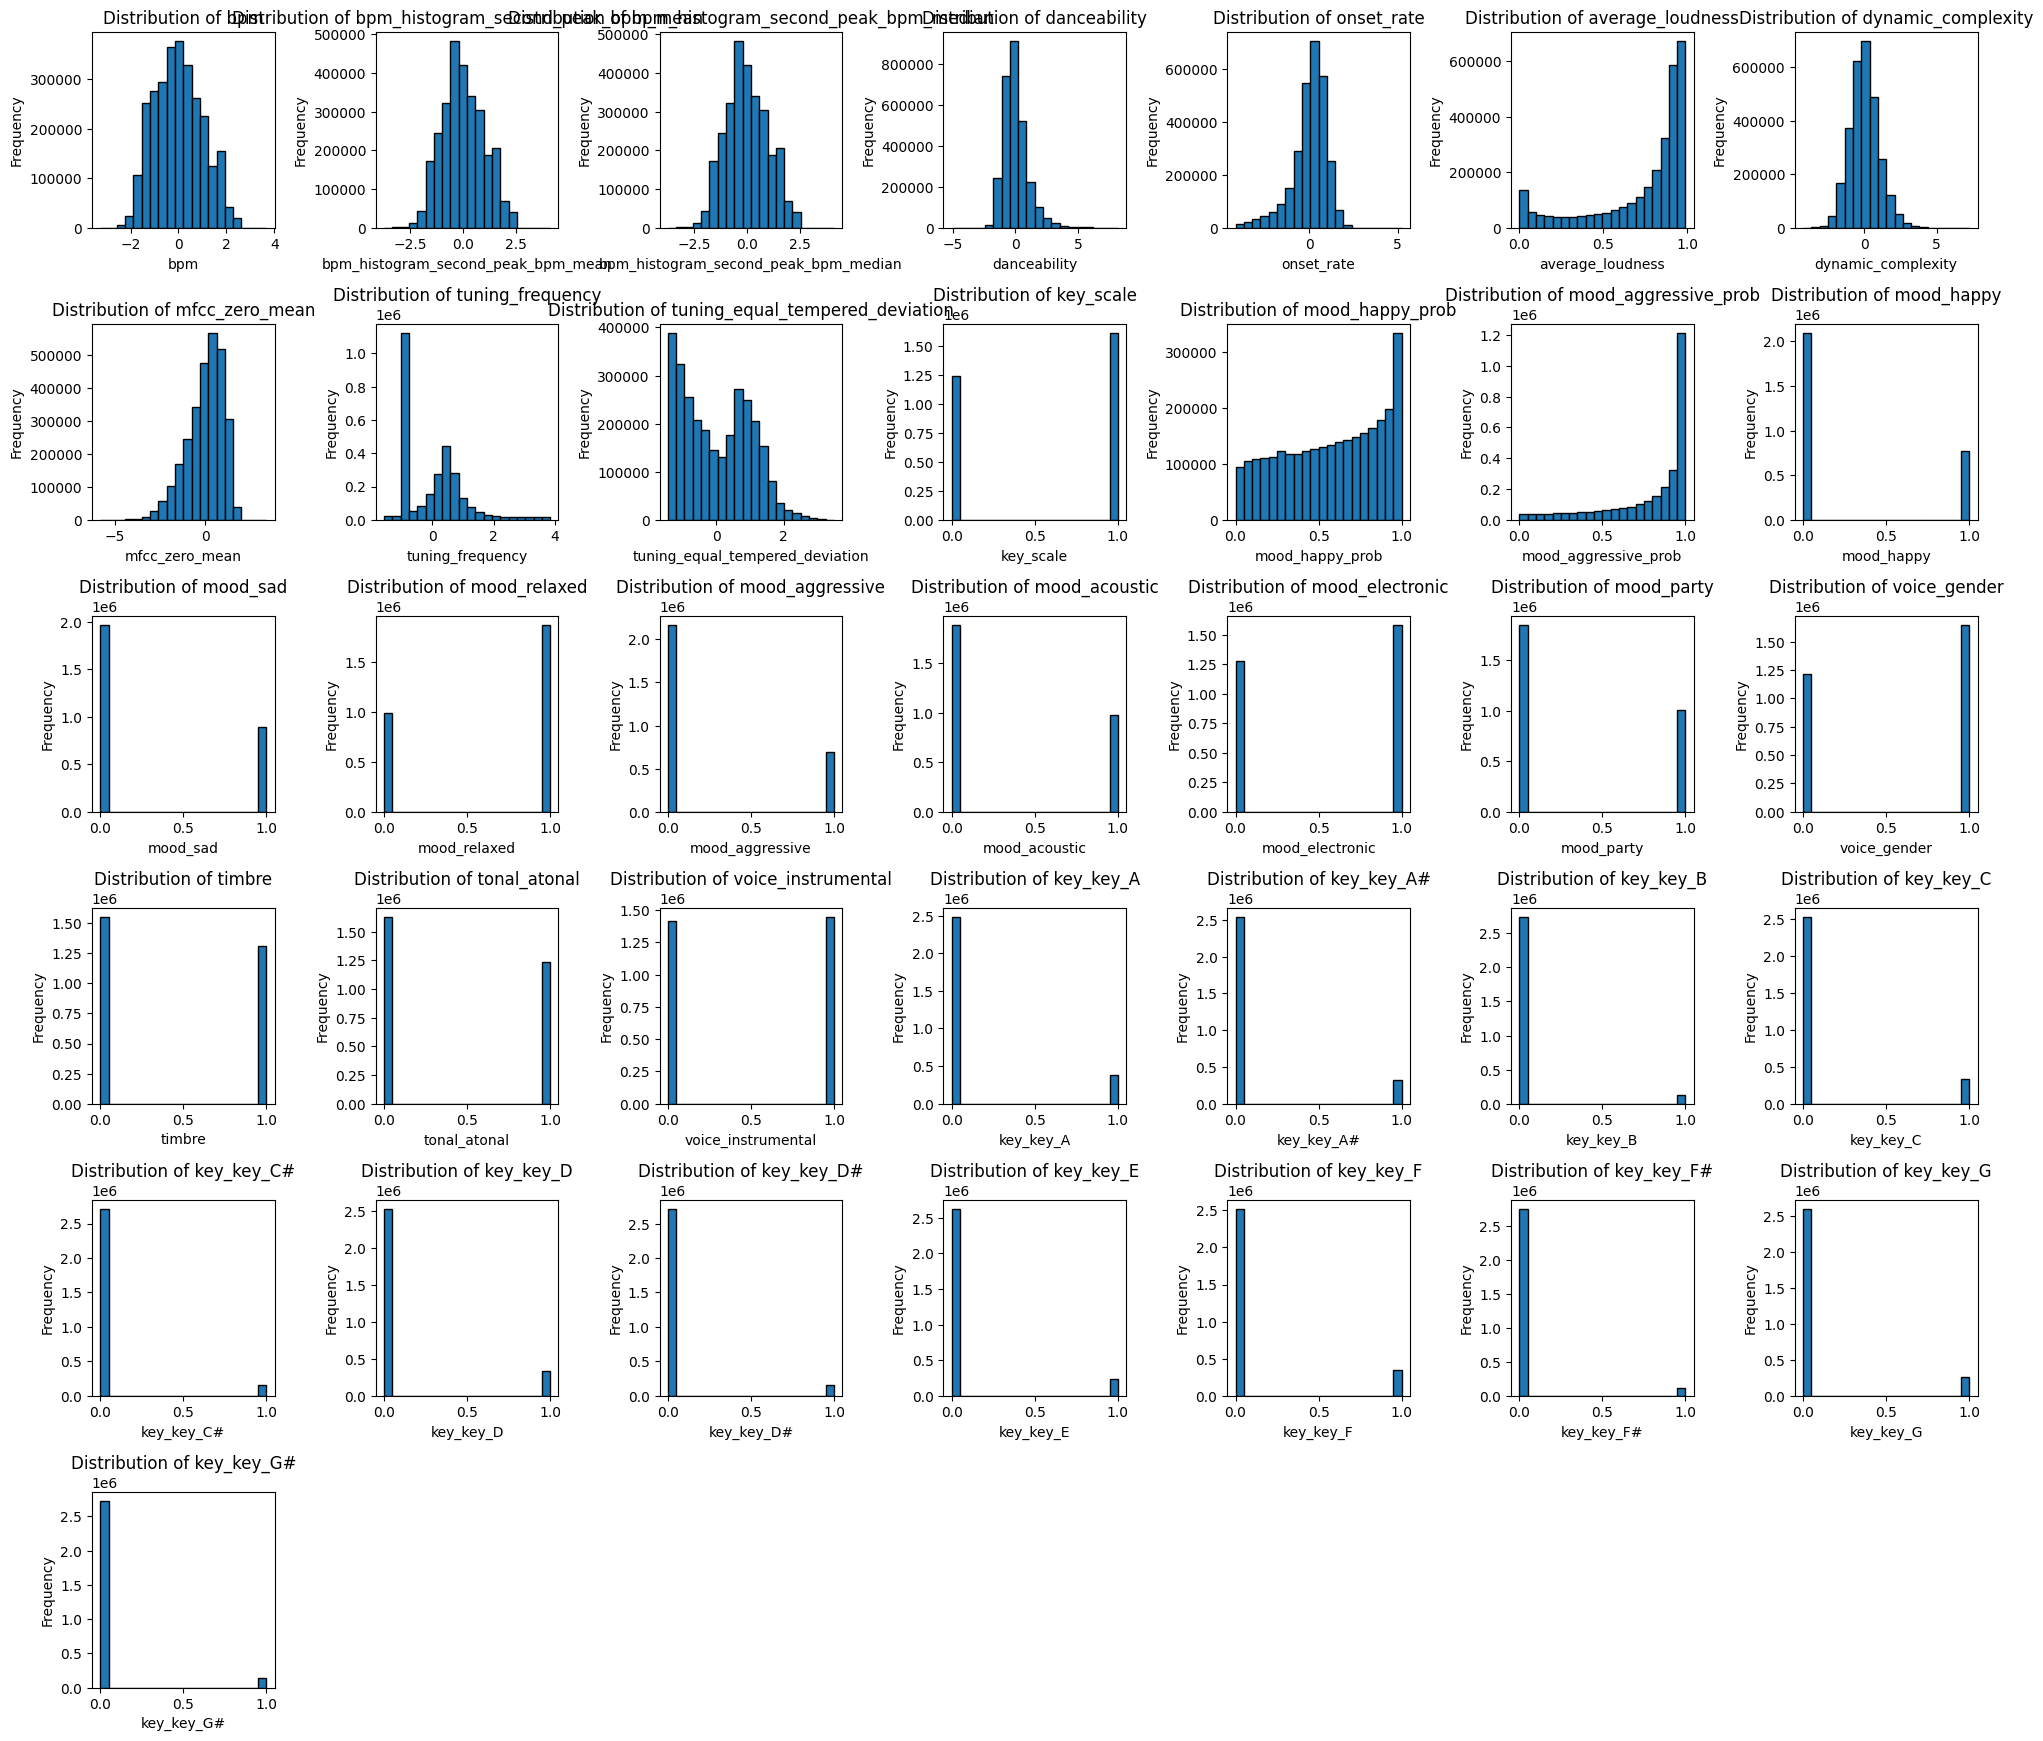

In [35]:
num_cols = len(scaled_X_train.columns)
n_cols = 7
n_rows = 7

fig, axes = plt.subplots(nrows=n_rows, ncols = n_cols, figsize=( 20,20))
axes = axes.flatten()

for i, col in enumerate(scaled_X_train.columns):
    axes[i].hist(scaled_X_train[col], bins = 20, edgecolor = 'black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for idx in range(num_cols, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

Output the scaled data to csv

In [36]:
scaled_X_train.to_csv('data/scaled_X_train.csv', index = False)
scaled_X_test.to_csv('data/scaled_X_test.csv', index = False)
y_train.to_csv('data/y_train.csv', index = False)
y_test.to_csv('data/y_test.csv', index = False)